In [2]:
from google.colab import drive
import zipfile
import os

# Mount Google Drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:

# Define paths
zip_path = "/content/drive/My Drive/archive 15000+15000=30000.zip"  # Change this
extract_path = "/content/unzipped_folder"  # Destination folder in Colab

# Create extraction directory
os.makedirs(extract_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# List extracted files
print("Unzipping done! Extracted files:")
for root, dirs, files in os.walk(extract_path):
    for file in files:
        print(os.path.join(root, file))



Streaming output truncated to the last 5000 lines.
/content/unzipped_folder/Negative/03677.jpg
/content/unzipped_folder/Negative/08392.jpg
/content/unzipped_folder/Negative/02097.jpg
/content/unzipped_folder/Negative/08437.jpg
/content/unzipped_folder/Negative/01852.jpg
/content/unzipped_folder/Negative/12392.jpg
/content/unzipped_folder/Negative/09609.jpg
/content/unzipped_folder/Negative/14501.jpg
/content/unzipped_folder/Negative/01610.jpg
/content/unzipped_folder/Negative/11517.jpg
/content/unzipped_folder/Negative/10667.jpg
/content/unzipped_folder/Negative/12391.jpg
/content/unzipped_folder/Negative/10060.jpg
/content/unzipped_folder/Negative/01562.jpg
/content/unzipped_folder/Negative/11933.jpg
/content/unzipped_folder/Negative/01237.jpg
/content/unzipped_folder/Negative/02098.jpg
/content/unzipped_folder/Negative/04758.jpg
/content/unzipped_folder/Negative/13262.jpg
/content/unzipped_folder/Negative/14192.jpg
/content/unzipped_folder/Negative/00500.jpg
/content/unzipped_folder/

In [4]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

Found 24000 images belonging to 2 classes.
Found 6000 images belonging to 2 classes.


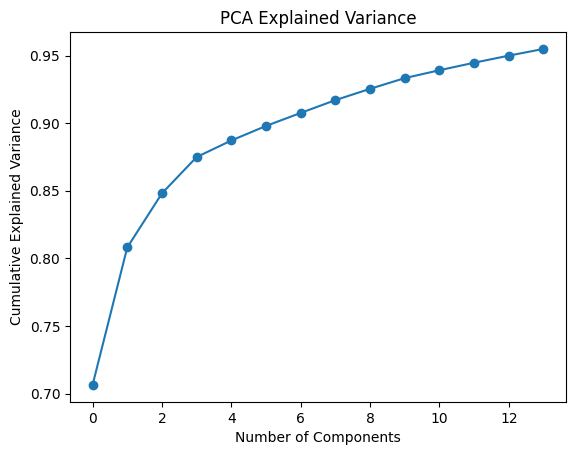

Feature Importances Computed.


In [5]:

# Define paths
base_dir = '/content/unzipped_folder'  # Update if necessary
positive_dir = os.path.join(base_dir, 'positive')  # Cracks present
negative_dir = os.path.join(base_dir, 'negative')  # No cracks

# Image parameters
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Data Augmentation
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2, rotation_range=20,
                                   width_shift_range=0.2, height_shift_range=0.2, shear_range=0.2,
                                   zoom_range=0.2, horizontal_flip=True, fill_mode='nearest')

train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=True
)

# Extract features and labels
X_train, y_train = next(train_generator)
X_val, y_val = next(val_generator)

# Flatten images for PCA analysis
X_train_flattened = X_train.reshape(X_train.shape[0], -1)
X_val_flattened = X_val.reshape(X_val.shape[0], -1)

# PCA Analysis
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_flattened)
X_val_pca = pca.transform(X_val_flattened)

plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

# Decision Tree Feature Importance (Using Flattened Data)
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train_flattened, y_train)
feature_importances = tree.feature_importances_
print("Feature Importances Computed.")

# Normalize Data using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_flattened)
X_val_scaled = scaler.transform(X_val_flattened)

# Label Encoding
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)


In [6]:
# Define Neural Network Model
model = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')  # Binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(train_generator, validation_data=val_generator, epochs=5, verbose=1)

# Evaluate Model
y_pred_prob = model.predict(val_generator)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

y_true = val_generator.classes
accuracy = accuracy_score(y_true, y_pred) * 100
print(f"Neural Network Accuracy: {accuracy:.2f}%")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 154s 199ms/step - accuracy: 0.7066 - loss: 0.5987 - val_accuracy: 0.8878 - val_loss: 0.3457
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 147s 196ms/step - accuracy: 0.8572 - loss: 0.3489 - val_accuracy: 0.9390 - val_loss: 0.2342
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 149s 199ms/step - accuracy: 0.9148 - loss: 0.2180 - val_accuracy: 0.9173 - val_loss: 0.2365
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 147s 196ms/step - accuracy: 0.9284 - loss: 0.1755 - val_accuracy: 0.9455 - val_loss: 0.1458
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 202s 196ms/step - accuracy: 0.9406 - loss: 0.1437 - val_accuracy: 0.9448 - val_loss: 0.1402
188/188 ━━━━━━━━━━━━━━━━━━━━ 29s 152ms/step
Neural Network Accuracy: 49.43%


TP: 1358, TN: 1608, FP: 1392, FN: 1642


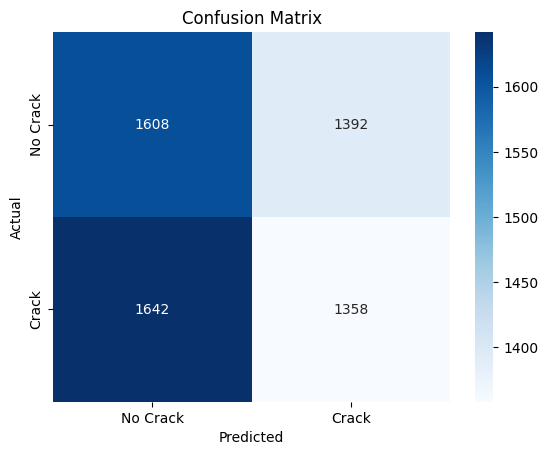

In [7]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
tp = conf_matrix[1, 1]
tn = conf_matrix[0, 0]
fp = conf_matrix[0, 1]
fn = conf_matrix[1, 0]
print(f"TP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}")

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Crack', 'Crack'], yticklabels=['No Crack', 'Crack'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Found 24000 images belonging to 2 classes.
Found 6000 images belonging to 2 classes.


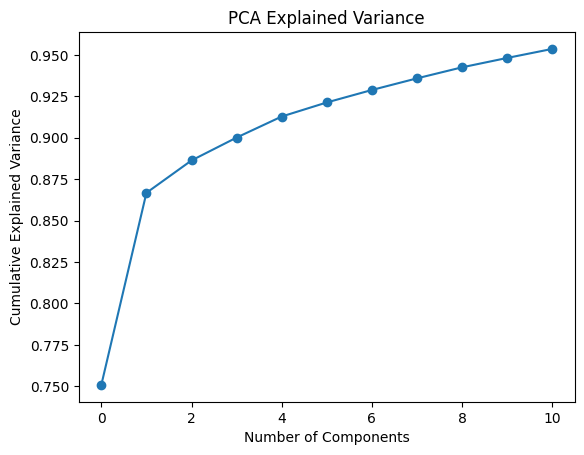

Feature Importances Computed.
KNN Accuracy: 65.62%
True Positives (TP): 9
True Negatives (TN): 12
False Positives (FP): 5
False Negatives (FN): 6


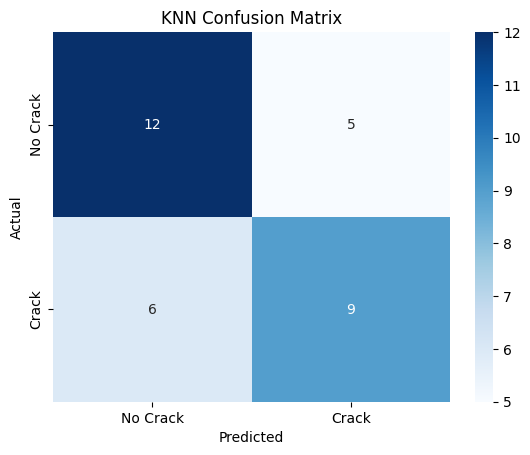

In [13]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE

# Define paths
base_dir = '/content/unzipped_folder'  # Update if necessary
positive_dir = os.path.join(base_dir, 'positive')  # Cracks present
negative_dir = os.path.join(base_dir, 'negative')  # No cracks

# Image parameters
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Data Augmentation
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2, rotation_range=20,
                                   width_shift_range=0.2, height_shift_range=0.2, shear_range=0.2,
                                   zoom_range=0.2, horizontal_flip=True, fill_mode='nearest')

train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=True
)

# Extract features and labels
X_train, y_train = next(train_generator)
X_val, y_val = next(val_generator)

# Flatten images for PCA analysis
X_train_flattened = X_train.reshape(X_train.shape[0], -1)
X_val_flattened = X_val.reshape(X_val.shape[0], -1)

# PCA Analysis
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_flattened)
X_val_pca = pca.transform(X_val_flattened)

plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

# Decision Tree Feature Importance (Using Flattened Data)
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train_flattened, y_train)
feature_importances = tree.feature_importances_
print("Feature Importances Computed.")

# Normalize Data using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_flattened)
X_val_scaled = scaler.transform(X_val_flattened)

# Label Encoding
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)


# Define KNN classifier
k = 5  # Number of neighbors, tune this for better performance
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train_scaled, y_train_encoded)

# Predict on validation data
y_pred_knn = knn.predict(X_val_scaled)

# Evaluate KNN model
accuracy_knn = accuracy_score(y_val_encoded, y_pred_knn) * 100
print(f"KNN Accuracy: {accuracy_knn:.2f}%")

# Compute Confusion Matrix
conf_matrix_knn = confusion_matrix(y_val_encoded, y_pred_knn)
tn, fp, fn, tp = conf_matrix_knn.ravel()  # Extract TP, TN, FP, FN

print(f"True Positives (TP): {tp}")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")

# Plot Confusion Matrix for KNN
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='Blues', xticklabels=['No Crack', 'Crack'], yticklabels=['No Crack', 'Crack'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('KNN Confusion Matrix')
plt.show()




Found 24000 images belonging to 2 classes.
Found 6000 images belonging to 2 classes.


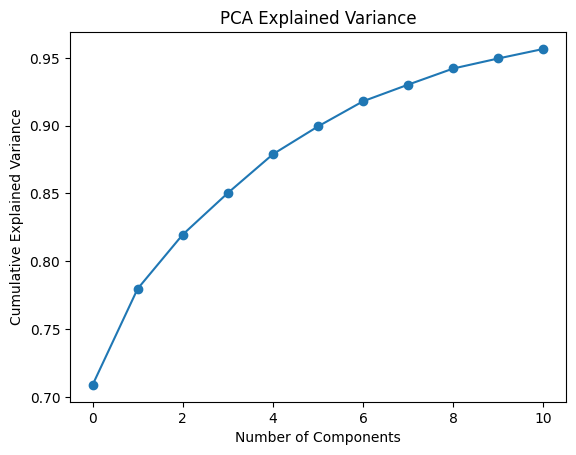

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:54:23] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:54:23] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:54:23] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:54:23] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:54:23] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

XGBoost Average Accuracy: 73.57%
Random Forest Average Accuracy: 86.79%
Final Model Accuracy: 75.00%
True Positives (TP): 15
True Negatives (TN): 9
False Positives (FP): 5
False Negatives (FN): 3


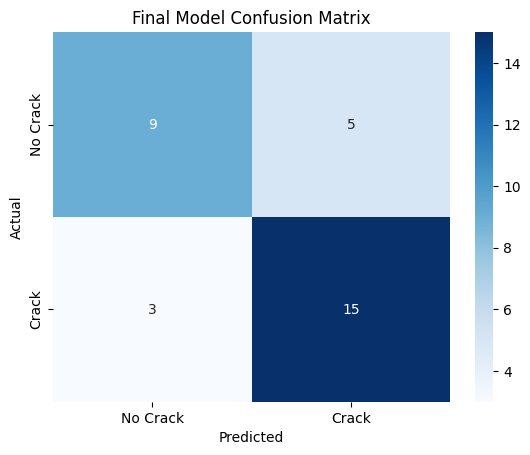

In [9]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Define paths
base_dir = '/content/unzipped_folder'  # Update if necessary
positive_dir = os.path.join(base_dir, 'positive')  # Cracks present
negative_dir = os.path.join(base_dir, 'negative')  # No cracks

# Image parameters
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Data Augmentation
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2, rotation_range=20,
                                   width_shift_range=0.2, height_shift_range=0.2, shear_range=0.2,
                                   zoom_range=0.2, horizontal_flip=True, fill_mode='nearest')

train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=True
)

# Extract features and labels
X_train, y_train = next(train_generator)
X_val, y_val = next(val_generator)

# Flatten images for PCA analysis
X_train_flattened = X_train.reshape(X_train.shape[0], -1)
X_val_flattened = X_val.reshape(X_val.shape[0], -1)

# PCA Analysis
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_flattened)
X_val_pca = pca.transform(X_val_flattened)

plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

# Normalize Data using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_pca)
X_val_scaled = scaler.transform(X_val_pca)

# Apply SMOTE to balance classes
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# Label Encoding
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_resampled)
y_val_encoded = label_encoder.transform(y_val)

# Define classifiers
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Stratified K-Fold Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_accuracies = []
rf_accuracies = []

for train_index, test_index in skf.split(X_train_resampled, y_train_encoded):
    X_train_fold, X_test_fold = X_train_resampled[train_index], X_train_resampled[test_index]
    y_train_fold, y_test_fold = y_train_encoded[train_index], y_train_encoded[test_index]

    # Train and evaluate XGBoost
    xgb_clf.fit(X_train_fold, y_train_fold)
    y_pred_xgb = xgb_clf.predict(X_test_fold)
    xgb_accuracies.append(accuracy_score(y_test_fold, y_pred_xgb))

    # Train and evaluate Random Forest
    rf_clf.fit(X_train_fold, y_train_fold)
    y_pred_rf = rf_clf.predict(X_test_fold)
    rf_accuracies.append(accuracy_score(y_test_fold, y_pred_rf))

# Compute average accuracy
print(f"XGBoost Average Accuracy: {np.mean(xgb_accuracies) * 100:.2f}%")
print(f"Random Forest Average Accuracy: {np.mean(rf_accuracies) * 100:.2f}%")

# Predict on validation set using the best model (XGBoost)
y_pred_final = xgb_clf.predict(X_val_scaled)

# Evaluate final model
accuracy_final = accuracy_score(y_val_encoded, y_pred_final) * 100
print(f"Final Model Accuracy: {accuracy_final:.2f}%")

# Compute Confusion Matrix
conf_matrix_final = confusion_matrix(y_val_encoded, y_pred_final)
tn, fp, fn, tp = conf_matrix_final.ravel()  # Extract TP, TN, FP, FN

print(f"True Positives (TP): {tp}")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")

sns.heatmap(conf_matrix_final, annot=True, fmt='d', cmap='Blues', xticklabels=['No Crack', 'Crack'], yticklabels=['No Crack', 'Crack'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Final Model Confusion Matrix')
plt.show()


Found 24000 images belonging to 2 classes.
Found 6000 images belonging to 2 classes.
Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.4458 - loss: 1.3650 - val_accuracy: 0.5000 - val_loss: 19.0268
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.5000 - loss: 20.7203 - val_accuracy: 0.5000 - val_loss: 11.3313
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.5000 - loss: 12.7502 - val_accuracy: 0.5000 - val_loss: 3.6528
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.5104 - loss: 3.7820 - val_accuracy: 0.5000 - val_loss: 5.9084
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.4896 - loss: 4.8556 - val_accuracy: 0.5000 - val_loss: 1.8108
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.5104 - loss: 4.1291 - val_accuracy: 0.5000 - val_loss: 3.5377
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5271 - loss: 4.3321 - val_accuracy: 0.5000 - val_loss: 2.3984
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.4896 - loss: 5.1940 - val_accuracy: 0.5000 - val_loss: 1.3243
Epoc

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:53:42] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
Logistic Regression - Accuracy: 59.38%, TP: 4, TN: 15, FP: 1, FN: 12


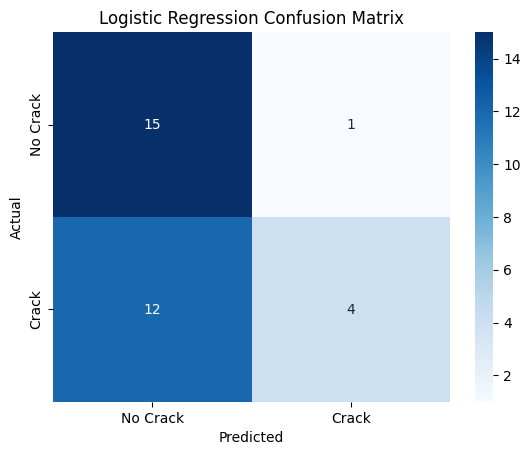

KNN - Accuracy: 46.88%, TP: 2, TN: 13, FP: 3, FN: 14


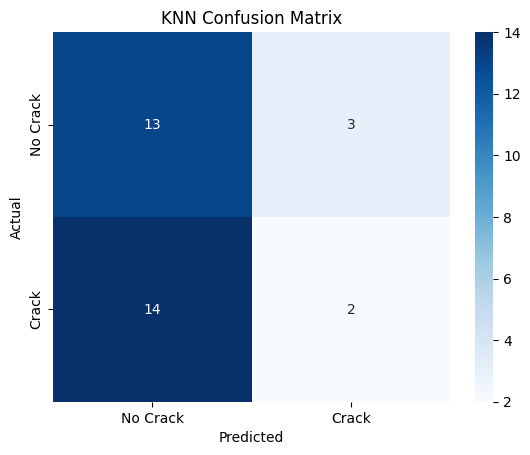

XGBoost - Accuracy: 59.38%, TP: 11, TN: 8, FP: 8, FN: 5


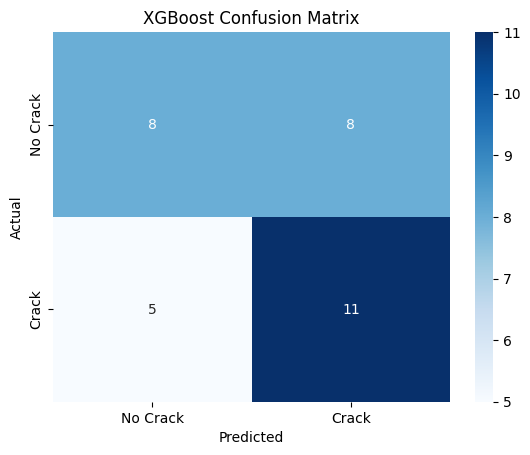

Ensemble - Accuracy: 56.25%, TP: 5, TN: 13, FP: 3, FN: 11


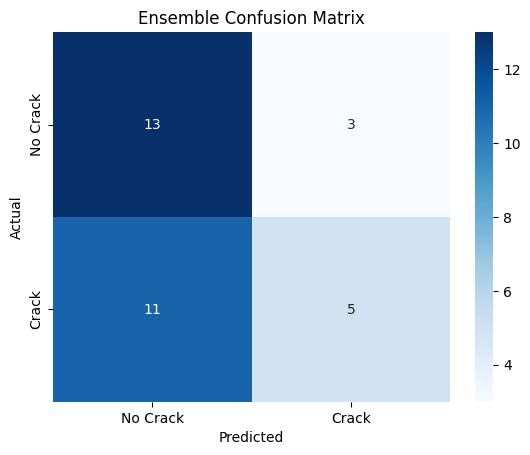

ANN - Accuracy: 50.00%, TP: 0, TN: 16, FP: 0, FN: 16


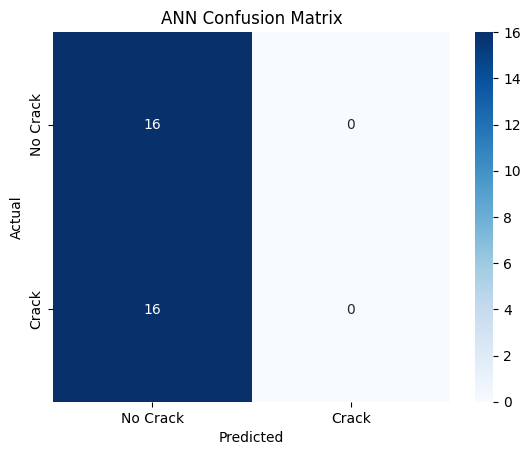

Total Average Accuracy: 54.38%


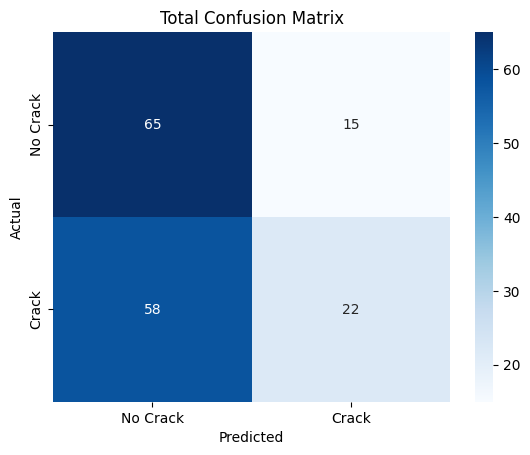

In [8]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import VotingClassifier

# Define paths
base_dir = '/content/unzipped_folder'  # Update if necessary

# Image parameters
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Data Augmentation
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2, rotation_range=20,
                                   width_shift_range=0.2, height_shift_range=0.2, shear_range=0.2,
                                   zoom_range=0.2, horizontal_flip=True, fill_mode='nearest')

train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=True
)

# Extract features and labels
X_train, y_train = next(train_generator)
X_val, y_val = next(val_generator)

# Flatten images for PCA analysis
X_train_flattened = X_train.reshape(X_train.shape[0], -1)
X_val_flattened = X_val.reshape(X_val.shape[0], -1)

# Normalize Data using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_flattened)
X_val_scaled = scaler.transform(X_val_flattened)

# Apply SMOTE to balance classes
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# Label Encoding
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_resampled)
y_val_encoded = label_encoder.transform(y_val)

# Stratified K-Fold Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define Models
log_reg = LogisticRegression()
knn = KNeighborsClassifier(n_neighbors=5)
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

def build_ann():
    model = Sequential([
        Flatten(input_shape=(X_train_scaled.shape[1],)),
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

ann_model = build_ann()
ann_model.fit(X_train_resampled, y_train_encoded, epochs=10, batch_size=32, validation_data=(X_val_scaled, y_val_encoded))

# Ensemble Model
ensemble = VotingClassifier(estimators=[('lr', log_reg), ('knn', knn), ('xgb', xgb)], voting='soft')
ensemble.fit(X_train_resampled, y_train_encoded)

# Predictions
y_pred_log = log_reg.fit(X_train_resampled, y_train_encoded).predict(X_val_scaled)
y_pred_knn = knn.fit(X_train_resampled, y_train_encoded).predict(X_val_scaled)
y_pred_xgb = xgb.fit(X_train_resampled, y_train_encoded).predict(X_val_scaled)
y_pred_ensemble = ensemble.predict(X_val_scaled)
y_pred_ann = (ann_model.predict(X_val_scaled) > 0.5).astype(int).flatten()

# Model Evaluations
models = {
    'Logistic Regression': y_pred_log,
    'KNN': y_pred_knn,
    'XGBoost': y_pred_xgb,
    'Ensemble': y_pred_ensemble,
    'ANN': y_pred_ann
}

total_accuracy = 0
total_cm = np.zeros((2, 2), dtype=int)

for model_name, y_pred in models.items():
    acc = accuracy_score(y_val_encoded, y_pred) * 100
    conf_matrix = confusion_matrix(y_val_encoded, y_pred)
    tn, fp, fn, tp = conf_matrix.ravel()
    total_accuracy += acc
    total_cm += conf_matrix
    print(f"{model_name} - Accuracy: {acc:.2f}%, TP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}")
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Crack', 'Crack'], yticklabels=['No Crack', 'Crack'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()

# Print total accuracy and confusion matrix
total_accuracy /= len(models)
print(f"Total Average Accuracy: {total_accuracy:.2f}%")
sns.heatmap(total_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Crack', 'Crack'], yticklabels=['No Crack', 'Crack'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Total Confusion Matrix')
plt.show()